In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"../../data/processed/cleaned3.csv"
df = pd.read_csv(file_path)


In [2]:
# Check for nulls in performance columns
print(df[['Performance Score', 'Current Employee Rating']].isnull().sum())

# Optional: Fill missing ratings (if any) with median or mode
df['Current Employee Rating'] = df['Current Employee Rating'].fillna(df['Current Employee Rating'].median())


Performance Score          0
Current Employee Rating    0
dtype: int64


Overall Performance Distribution

C:\Users\alanm\AppData\Local\Temp\ipykernel_25660\3945095144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Performance Score', palette='Set2')


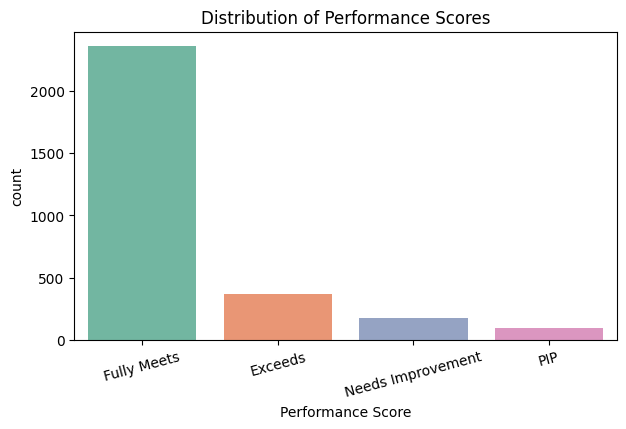

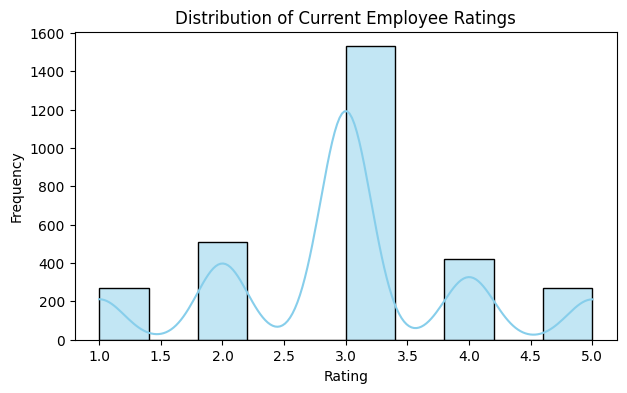

In [3]:
# Plot Performance Score distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Performance Score', palette='Set2')
plt.title("Distribution of Performance Scores")
plt.xticks(rotation=15)
plt.show()

# Plot Current Employee Rating distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['Current Employee Rating'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Current Employee Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


Performance by Department / Job Family

C:\Users\alanm\AppData\Local\Temp\ipykernel_25660\3582384248.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JobFamily', y='Current Employee Rating', palette='coolwarm')


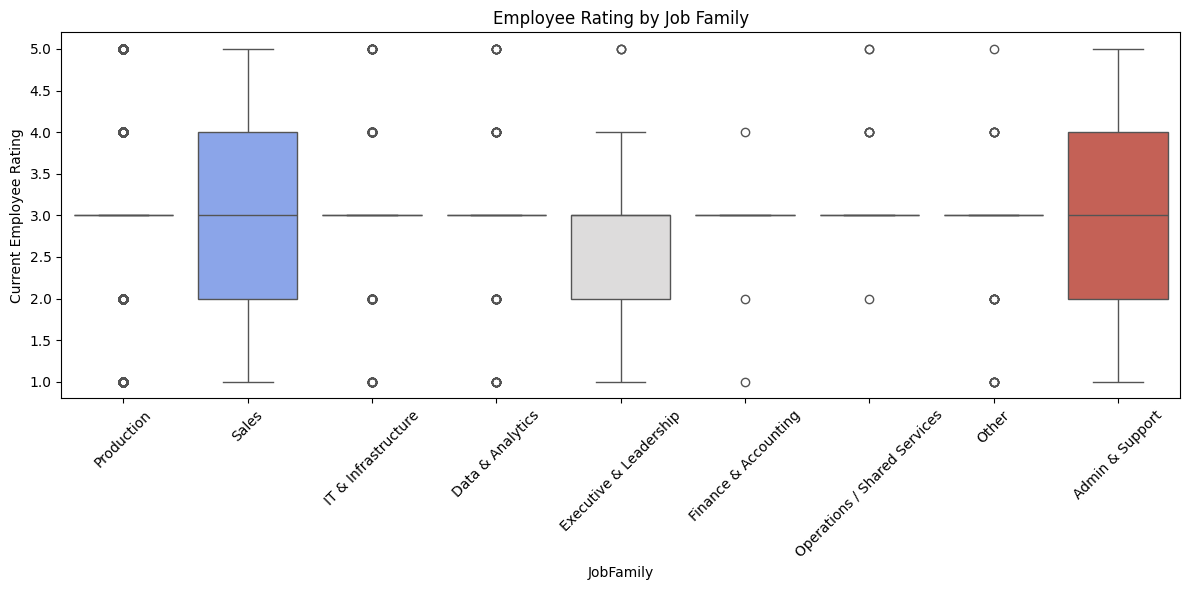

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='JobFamily', y='Current Employee Rating', palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Employee Rating by Job Family")
plt.tight_layout()
plt.show()


Performance by Department / Job Family

C:\Users\alanm\AppData\Local\Temp\ipykernel_25660\3582384248.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JobFamily', y='Current Employee Rating', palette='coolwarm')


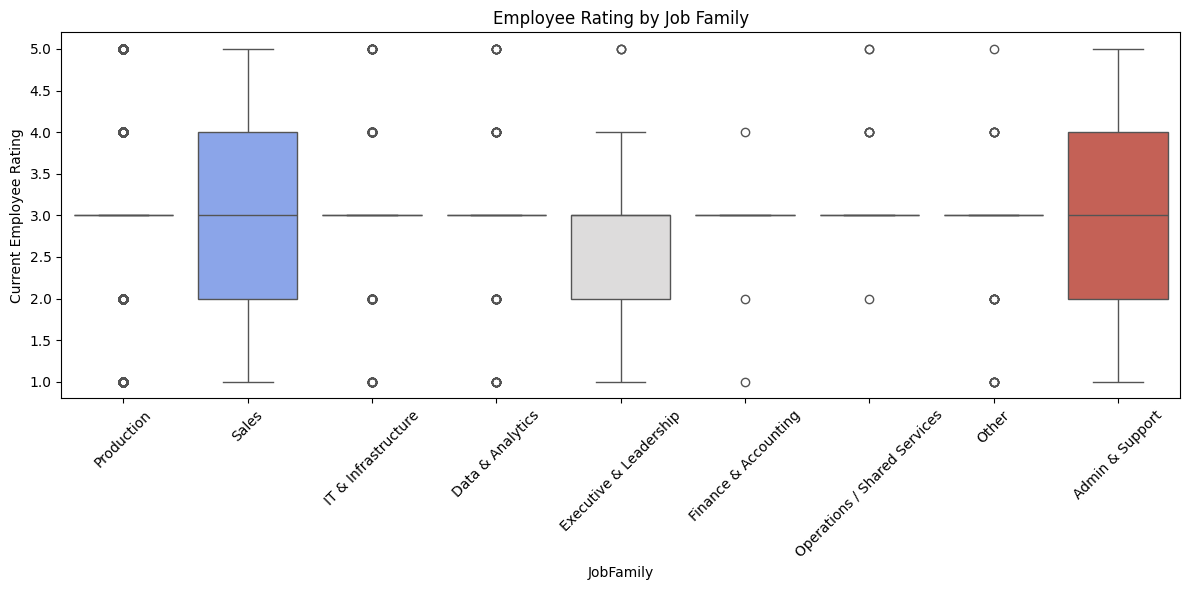

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='JobFamily', y='Current Employee Rating', palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Employee Rating by Job Family")
plt.tight_layout()
plt.show()


Performance by Gender / Race

C:\Users\alanm\AppData\Local\Temp\ipykernel_25660\3556860973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='GenderCode', y='Current Employee Rating', palette='pastel')


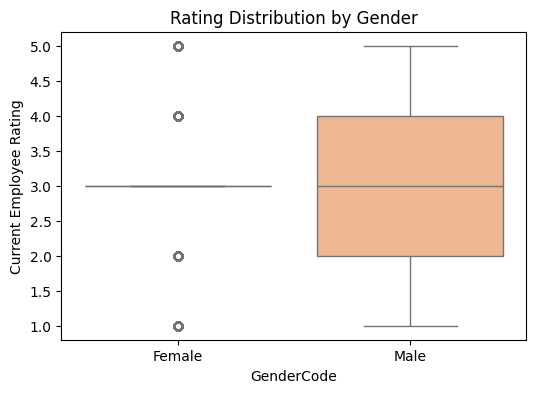

C:\Users\alanm\AppData\Local\Temp\ipykernel_25660\3556860973.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RaceDesc', y='Current Employee Rating', palette='Set3')


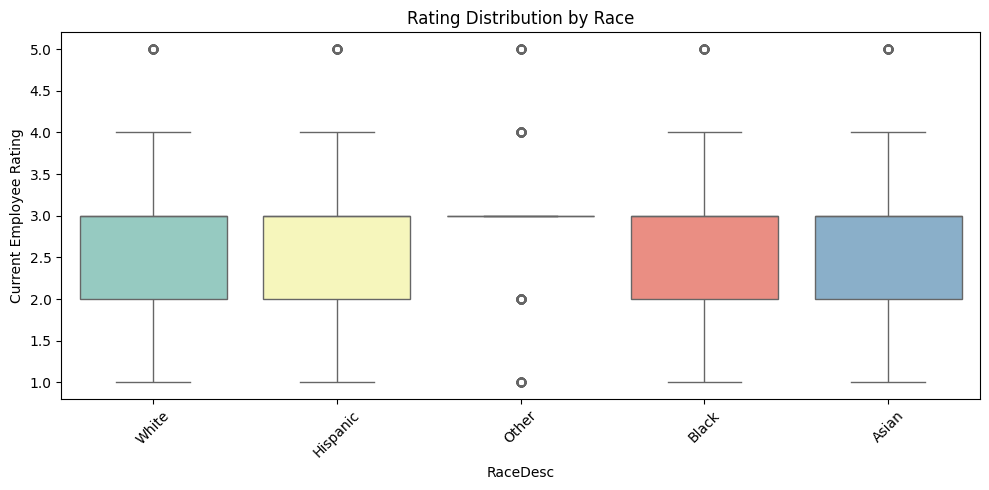

In [6]:
# By Gender
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='GenderCode', y='Current Employee Rating', palette='pastel')
plt.title("Rating Distribution by Gender")
plt.show()

# By Race
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='RaceDesc', y='Current Employee Rating', palette='Set3')
plt.xticks(rotation=45)
plt.title("Rating Distribution by Race")
plt.tight_layout()
plt.show()


Identify High & Low Performers

In [7]:
# Define thresholds (adjust as needed)
high_perf = df[df['Current Employee Rating'] >= 4.5]
low_perf = df[df['Current Employee Rating'] <= 2.0]

print("🔝 High Performers:", len(high_perf))
print("🔻 Low Performers:", len(low_perf))

# Check their JobFamily and Seniority
print("\nHigh Performers by Job Family:\n", high_perf['JobFamily'].value_counts())
print("\nLow Performers by Job Family:\n", low_perf['JobFamily'].value_counts())


🔝 High Performers: 270
🔻 Low Performers: 781

High Performers by Job Family:
 JobFamily
Production                      188
Sales                            45
IT & Infrastructure              19
Data & Analytics                  8
Admin & Support                   4
Executive & Leadership            3
Operations / Shared Services      2
Other                             1
Name: count, dtype: int64

Low Performers by Job Family:
 JobFamily
Production                      495
Sales                           148
IT & Infrastructure              59
Data & Analytics                 34
Other                            16
Executive & Leadership           14
Admin & Support                  12
Finance & Accounting              2
Operations / Shared Services      1
Name: count, dtype: int64


✅ Insights You Can Extract:

- Which departments or roles have the most high or low performers?

- Are certain demographic groups underperforming?

- Are senior employees consistently rated higher?

- Are there performance gaps that need intervention or training?

| Step | What We Analyzed                                         | Why It's Important                                                                                                                                    |
| ---- | -------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1️⃣  | **Distribution of Performance Score & Employee Ratings** | To get an overall view of how employee performance is spread across the organization. Helps identify if most employees are performing well or poorly. |
| 2️⃣  | **Performance by JobFamily**                             | To detect departments/roles where performance is consistently high or low. Useful for role-specific training or promotions.                           |
| 3️⃣  | **Performance by Gender and Race**                       | To ensure fairness and spot potential performance disparities that could indicate bias or inequality.                                                 |
| 4️⃣  | **High vs Low Performers Segmentation**                  | To identify top performers for leadership roles or rewards, and low performers for intervention or development.                                       |


| Visualization                                       | Reason for Choosing                                                                                                                                  |
| --------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`countplot` for Performance Score**               | Ideal for categorical/discrete data to see how many employees fall into each performance category.                                                   |
| **`histplot` for Current Employee Rating**          | Shows distribution and shape of continuous rating scores, helping understand whether most employees are rated average, high, or low.                 |
| **`boxplot` by JobFamily, Gender, and Race**        | Boxplots are perfect for comparing distributions of a numerical variable across categories. They highlight median performance, outliers, and spread. |
| **`value_counts()` tables for high/low performers** | Quick summary to count and compare the number of top or underperforming employees across key job segments.                                           |
